In [275]:
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import warnings

warnings.WarningMessage
warnings.filterwarnings("ignore")

In [276]:
data = sns.load_dataset("tips")
data.head(300)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [277]:
features = data[['total_bill']]
tip = data['tip']

from sklearn import linear_model


In [278]:
f = linear_model.LinearRegression(fit_intercept=False)
f.fit(features,tip)

LinearRegression(fit_intercept=False)

In [279]:
# in house table bill
f.predict([[0]])

array([0.])

In [280]:

# table bill of $100
f.predict([[100]])

array([14.37318953])

In [281]:
# zero intercept
f.coef_ 

array([0.1437319])

In [282]:
# zero slope
f.intercept_

0.0

In [283]:
#add predictions to dataframe
data['prediction'] = f.predict(features)

In [284]:
data.head(30)

,total_bill,tip,sex,smoker,day,time,size,prediction
0,16.99,1.01,Female,No,Sun,Dinner,2,2.442005
1,10.34,1.66,Male,No,Sun,Dinner,3,1.486188
2,21.01,3.50,Male,No,Sun,Dinner,3,3.019807
3,23.68,3.31,Male,No,Sun,Dinner,2,3.403571
4,24.59,3.61,Female,No,Sun,Dinner,4,3.534367
5,25.29,4.71,Male,No,Sun,Dinner,4,3.634980
6,8.77,2.00,Male,No,Sun,Dinner,2,1.260529
7,26.88,3.12,Male,No,Sun,Dinner,4,3.863513
8,15.04,1.96,Male,No,Sun,Dinner,2,2.161728
9,14.78,3.23,Male,No,Sun,Dinner,2,2.124357


In [285]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=data['total_bill'], y = data['tip'], mode = "markers", name = "actual"))
fig.add_trace(go.Scatter(x=data['total_bill'], y = data['prediction'], mode = "lines", name = "predicted"))
fig.update_layout(font_size = 20)

### Y = intercept + slop * X
##### y = 0.1437 * x

In [286]:
#get coefficients and intercept
coef = f.coef_
intercept = f.intercept_
intercept, coef[0]

(0.0, 0.14373189527721664)

In [287]:
#fit with intercept
f_w_int = linear_model.LinearRegression(fit_intercept=True)
f_w_int.fit(features,tip)

LinearRegression()

In [288]:
#f_w_int.predict([[100]])
f_w_int.predict([[100]])

array([11.42272135])

### Y = intercept + slop * X
##### y =0.92 +  0.105 * x

In [289]:
#get coefficient and intercept for new model
coef_w_int = f_w_int.coef_
intercept_w_int = f_w_int.intercept_
intercept_w_int, coef_w_int[0]

(0.9202696135546731, 0.10502451738435337)

In [290]:
# add prediction_with_intercept column to the data DataFrame
data['prediction_with_intercept'] = f_w_int.predict(features)
data.head()

,total_bill,tip,sex,smoker,day,time,size,prediction,prediction_with_intercept
0,16.99,1.01,Female,No,Sun,Dinner,2,2.442005,2.704636
1,10.34,1.66,Male,No,Sun,Dinner,3,1.486188,2.006223
2,21.01,3.50,Male,No,Sun,Dinner,3,3.019807,3.126835
3,23.68,3.31,Male,No,Sun,Dinner,2,3.403571,3.407250
4,24.59,3.61,Female,No,Sun,Dinner,4,3.534367,3.502822


In [291]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=data['total_bill'], y = data['tip'], mode = "markers", name = "actual"))
fig.add_trace(go.Scatter(x=data['total_bill'], y = data['prediction'], mode = "lines", name = "prediction (b = 0)"))
fig.add_trace(go.Scatter(x=data['total_bill'], y = data['prediction_with_intercept'], mode = "lines", name = "predicted (b ≠ 0)"))
fig.update_layout(font_size = 20)

### Using Plotly

In [292]:
fig = px.scatter(data, x = "total_bill", y = "tip", trendline = "ols", trendline_color_override="red")
fig.update_layout(font_size = 20)

In [293]:
fig = px.scatter(data, x = "total_bill", y = "tip", trendline = "ols", trendline_color_override="red")
results = px.get_trendline_results(fig)
results.px_fit_results.iloc[0].params

array([0.92026961, 0.10502452])

## Loss Functions

### Computing the L2 Loss and MSE
#### L2 = (y -yhat)**2 = (data['tip'] - data['prediction']) ** 2

In [294]:
data = sns.load_dataset("tips")
data["prediction"] = f.predict(data[["total_bill"]])
data.head(5)

,total_bill,tip,sex,smoker,day,time,size,prediction
0,16.99,1.01,Female,No,Sun,Dinner,2,2.442005
1,10.34,1.66,Male,No,Sun,Dinner,3,1.486188
2,21.01,3.50,Male,No,Sun,Dinner,3,3.019807
3,23.68,3.31,Male,No,Sun,Dinner,2,3.403571
4,24.59,3.61,Female,No,Sun,Dinner,4,3.534367


In [295]:
# add loss to the dataframe
data["L2_loss"] = (data["tip"] - data["prediction"])**2
data.head(300)

,total_bill,tip,sex,smoker,day,time,size,prediction,L2_loss
0,16.99,1.01,Female,No,Sun,Dinner,2,2.442005,2.050638
1,10.34,1.66,Male,No,Sun,Dinner,3,1.486188,0.030211
2,21.01,3.50,Male,No,Sun,Dinner,3,3.019807,0.230585
3,23.68,3.31,Male,No,Sun,Dinner,2,3.403571,0.008756
4,24.59,3.61,Female,No,Sun,Dinner,4,3.534367,0.005720
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,4.172537,3.053627
240,27.18,2.00,Female,Yes,Sat,Dinner,2,3.906633,3.635249
241,22.67,2.00,Male,Yes,Sat,Dinner,2,3.258402,1.583576
242,17.82,1.75,Male,No,Sat,Dinner,2,2.561302,0.658212


In [296]:
data["L2_loss"].mean()

1.1781161154513171

In [297]:
#compute the mean
np.mean(data["L2_loss"])

1.1781161154513171

In [298]:
## or we can compute MSE directly from the outcome and predictions using mean_squared_error
from sklearn.metrics import mean_squared_error
mean_squared_error(data["tip"], data["prediction"])

1.1781161154513171

In [299]:
mean_squared_error(data["tip"], f.predict(data[["total_bill"]]))

1.1781161154513171

#### SciPy LinearRegression

In [300]:
from scipy import stats

X = data['total_bill']
y = data['tip']
res = stats.linregress(X, y)
slope= res.slope
intercept = res.intercept
se = res.stderr
stderr = res.intercept_stderr

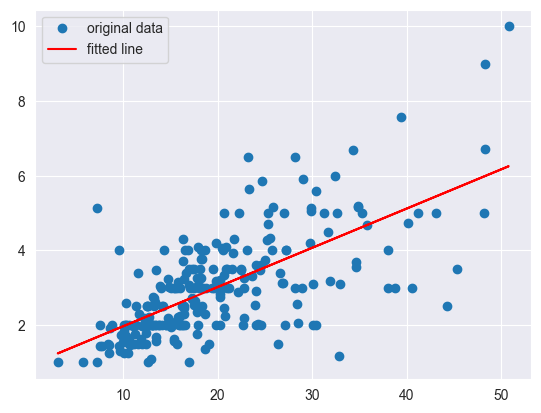

In [301]:
import matplotlib.pyplot as plt

plt.plot(X, y, 'o', label='original data')
plt.plot(X, res.intercept + res.slope*X, 'r', label='fitted line')
plt.legend()
plt.show()

### Understanding that MSE is a Function of One Variable

In [302]:
# replace the prediction column and L2 loss columns with the corresponding values for 20% tip
data = sns.load_dataset("tips")
data['prediction'] = data['total_bill'] * 0.2
data['l2_loss'] = (data['prediction'] - data['tip']) ** 2
data.head(300)

,total_bill,tip,sex,smoker,day,time,size,prediction,l2_loss
0,16.99,1.01,Female,No,Sun,Dinner,2,3.398,5.702544
1,10.34,1.66,Male,No,Sun,Dinner,3,2.068,0.166464
2,21.01,3.50,Male,No,Sun,Dinner,3,4.202,0.492804
3,23.68,3.31,Male,No,Sun,Dinner,2,4.736,2.033476
4,24.59,3.61,Female,No,Sun,Dinner,4,4.918,1.710864
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,5.806,0.012996
240,27.18,2.00,Female,Yes,Sat,Dinner,2,5.436,11.806096
241,22.67,2.00,Male,Yes,Sat,Dinner,2,4.534,6.421156
242,17.82,1.75,Male,No,Sat,Dinner,2,3.564,3.290596


In [303]:
# compute the mean_squared_error for 20% tip
mean_squared_error(data["tip"], data["prediction"], )

2.667486278688525

In [304]:
# compute error for a 20% tip on one line (without creating prediction and L2 loss column)
mean_squared_error(data['tip'], data['total_bill'] * 0.2)

2.667486278688525

In [305]:
# compute error for various % tip values
mean_squared_error(data['tip'], data['total_bill'] * 0.08)

3.08881276852459

In [306]:
mean_squared_error(data['tip'], data['total_bill'] * 0.2)

2.667486278688525

In [307]:
mean_squared_error(data['tip'], data['total_bill'] * 0.3)

12.66543732377049

In [308]:
# define a function mse_given_theta as a function which takes theta
# and computes RMSE
def mse_given_theta(theta):
    return mean_squared_error(data["tip"], data["total_bill"]*theta)

In [309]:
# create a list of thetas
thetas = np.linspace(0.1, 0.2, 100)
thetas

array([0.1       , 0.1010101 , 0.1020202 , 0.1030303 , 0.1040404 ,
       0.10505051, 0.10606061, 0.10707071, 0.10808081, 0.10909091,
       0.11010101, 0.11111111, 0.11212121, 0.11313131, 0.11414141,
       0.11515152, 0.11616162, 0.11717172, 0.11818182, 0.11919192,
       0.12020202, 0.12121212, 0.12222222, 0.12323232, 0.12424242,
       0.12525253, 0.12626263, 0.12727273, 0.12828283, 0.12929293,
       0.13030303, 0.13131313, 0.13232323, 0.13333333, 0.13434343,
       0.13535354, 0.13636364, 0.13737374, 0.13838384, 0.13939394,
       0.14040404, 0.14141414, 0.14242424, 0.14343434, 0.14444444,
       0.14545455, 0.14646465, 0.14747475, 0.14848485, 0.14949495,
       0.15050505, 0.15151515, 0.15252525, 0.15353535, 0.15454545,
       0.15555556, 0.15656566, 0.15757576, 0.15858586, 0.15959596,
       0.16060606, 0.16161616, 0.16262626, 0.16363636, 0.16464646,
       0.16565657, 0.16666667, 0.16767677, 0.16868687, 0.16969697,
       0.17070707, 0.17171717, 0.17272727, 0.17373737, 0.17474

In [310]:
# compute MSEs for those thetas
mses = [mse_given_theta(theta) for theta in thetas]
mses

[2.0777683729508194,
 2.0366887534058913,
 1.996569059699077,
 1.9574092918303747,
 1.919209449799786,
 1.8819695336073097,
 1.8456895432529465,
 1.8103694787366964,
 1.7760093400585586,
 1.7426091272185338,
 1.7101688402166224,
 1.678688479052823,
 1.6481680437271375,
 1.6186075342395636,
 1.5900069505901033,
 1.5623662927787565,
 1.5356855608055218,
 1.5099647546704,
 1.4852038743733909,
 1.461402919914495,
 1.4385618912937121,
 1.4166807885110417,
 1.3957596115664843,
 1.37579836046004,
 1.3567970351917082,
 1.3387556357614898,
 1.3216741621693837,
 1.3055526144153906,
 1.2903909924995107,
 1.2761892964217436,
 1.262947526182089,
 1.2506656817805475,
 1.2393437632171185,
 1.2289817704918033,
 1.2195797036046003,
 1.2111375625555103,
 1.2036553473445333,
 1.197133057971669,
 1.1915706944369175,
 1.1869682567402793,
 1.1833257448817533,
 1.1806431588613406,
 1.1789204986790405,
 1.1781577643348538,
 1.1783549558287796,
 1.1795120731608182,
 1.18162911633097,
 1.1847060853392344,
 1.18

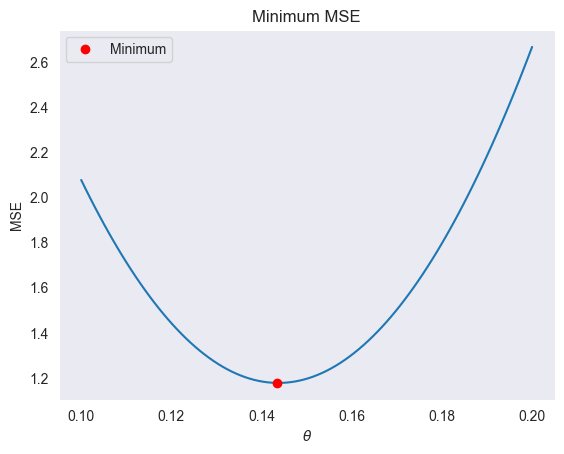

In [311]:
# plot MSE vs theta, showing off how to set xaxis_title and yaxis_title
plt.plot(thetas, mses)
plt.plot(thetas[np.argmin(mses)], min(mses), 'ro', label = 'Minimum')
plt.legend()
plt.title('Minimum MSE')
plt.xlabel(r'$\theta$')
plt.ylabel('MSE')
plt.grid();

In [312]:
fig = px.line(x = thetas, y = mses)
fig.add_trace(go.Scatter(x=[thetas[np.argmin(mses)]], y = [min(mses)], marker = dict(color="red", size=12),mode="markers",name = 'Minimum'))
fig.update_layout(xaxis_title = "θ", yaxis_title = "MSE", font_size = 20)
fig.show()

## Minimizing a Function Using Scipy Optimize

In [313]:
import scipy.optimize

In [314]:
# define g as the cube of x plus square of x minus 3 times x plus 2
def g(x):
    return x**3 + x**2 - 3*x + 2

In [315]:
# try to minimize g manually
g(12)

1838

In [316]:
# use scipy.optimize.minimize and compare with wolfram alpha
scipy.optimize.minimize(g, x0 = 1000)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.7316461776530541
        x: [ 7.208e-01]
      nit: 20
      jac: [ 1.788e-07]
 hess_inv: [[ 1.580e-01]]
     nfev: 48
     njev: 24

In [317]:
# visualize g
px.line(x=np.linspace(-3,2,1000), y=g(np.linspace(-3,2,1000)))

In [318]:
scipy.optimize.minimize(mse_given_theta,x0=0.2)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.1781161154513287
        x: [ 1.437e-01]
      nit: 1
      jac: [ 2.384e-06]
 hess_inv: [[1]]
     nfev: 6
     njev: 3

## Multiple Linear Regression

In [319]:
# fit a model on total_bill and size
two_features = data[["total_bill", "size"]]
tip = data["tip"]

f2 = linear_model.LinearRegression(fit_intercept = False)
f2.fit(two_features, tip)

LinearRegression(fit_intercept=False)

In [320]:
#show coefficients
f2.coef_

array([0.1007119 , 0.36209717])

In [321]:
# make a prediction for a table with $10 total bill and 3 people seated
f2.predict([[10, 3]])

array([2.09341054])

In [322]:
# compare predictions for f and f2 side by side in table
f.predict([[10]])

array([1.43731895])

In [323]:
data["prediction"] = f.predict(data[["total_bill"]])

In [324]:
data["prediction_2d"] = f2.predict(data[["total_bill", "size"]])
data.head(5)

,total_bill,tip,sex,smoker,day,time,size,prediction,l2_loss,prediction_2d
0,16.99,1.01,Female,No,Sun,Dinner,2,2.442005,5.702544,2.435290
1,10.34,1.66,Male,No,Sun,Dinner,3,1.486188,0.166464,2.127653
2,21.01,3.50,Male,No,Sun,Dinner,3,3.019807,0.492804,3.202249
3,23.68,3.31,Male,No,Sun,Dinner,2,3.403571,2.033476,3.109052
4,24.59,3.61,Female,No,Sun,Dinner,4,3.534367,1.710864,3.924894


In [325]:
# compare MSE f vs f2 
mean_squared_error(data['prediction'], data['tip'])

1.1781161154513171

In [326]:
mean_squared_error(data['prediction_2d'], data['tip'])

1.06482122862577

In [327]:
# plot 3d data
px.scatter_3d(data, x = "total_bill", y = "size", z = "tip")

In [328]:
# This code is not something we expect you to understand!
# It's just computing predictions for various bills and table sizes
table_bills, table_sizes = np.meshgrid(range(50), range(6))
tip_predictions = ( 0.1007119 * table_bills + 0.3621 * table_sizes)

In [329]:
fig = go.Figure()
fig.add_trace(go.Scatter3d(x = data["total_bill"], y = data["size"], z = data["tip"], mode = "markers", name = "actual"))
fig.add_trace(go.Surface(x = table_bills, y = table_sizes, z = tip_predictions, name = "predicted"))
fig.show()

In [330]:
# compare MSE for f and f2 

### Using Non-numeric Features

In [331]:
# show rows from different days of the week
data = sns.load_dataset("tips")
data.iloc[[193, 90, 25, 26, 190], :]

,total_bill,tip,sex,smoker,day,time,size
193,15.48,2.02,Male,Yes,Thur,Lunch,2
90,28.97,3.00,Male,Yes,Fri,Dinner,2
25,17.81,2.34,Male,No,Sat,Dinner,4
26,13.37,2.00,Male,No,Sat,Dinner,2
190,15.69,1.50,Male,Yes,Sun,Dinner,2


In [332]:
# create a copy of the dataset that only has 3 features in order to keep things simple
three_features = ['total_bill', 'size', 'day']

three_feature_data = pd.DataFrame(data[three_features])
three_feature_data.head(5)

,total_bill,size,day
0,16.99,2,Sun
1,10.34,3,Sun
2,21.01,3,Sun
3,23.68,2,Sun
4,24.59,4,Sun


In [333]:
# let's create "dummies" that represent whether it is thursday, friday, saturday, or sunday
dummies = pd.get_dummies(three_feature_data['day']).astype(int)
dummies.iloc[[193, 90, 25, 26, 190], :]

,Thur,Fri,Sat,Sun
193,1,0,0,0
90,0,1,0,0
25,0,0,1,0
26,0,0,1,0
190,0,0,0,1


In [334]:
# concatenate the dummies table with three_feature_data
data_w_dummies = pd.concat([three_feature_data, dummies], axis=1)
data_w_dummies.iloc[[193, 90, 25, 26, 190], :]

,total_bill,size,day,Thur,Fri,Sat,Sun
193,15.48,2,Thur,1,0,0,0
90,28.97,2,Fri,0,1,0,0
25,17.81,4,Sat,0,0,1,0
26,13.37,2,Sat,0,0,1,0
190,15.69,2,Sun,0,0,0,1


In [335]:
data_w_dummies.drop(columns=['day'], inplace=True)

In [336]:
# The code below will crash since data_w_dummies includes a non-numeric feature
f_with_day = linear_model.LinearRegression(fit_intercept=False)
f_with_day.fit(data_w_dummies, tip)

LinearRegression(fit_intercept=False)

In [337]:
# drop the non-numeric column
del data_w_dummies["day"]
data_w_dummies.head(5)

KeyError: 'day'

In [ ]:
# fit the model
f_with_day = linear_model.LinearRegression(fit_intercept=False)
f_with_day.fit(data_w_dummies, tip)

In [338]:
# get the coefficients
f_with_day.coef_

array([0.09299361, 0.18713231, 0.66829361, 0.74578683, 0.62112858,
       0.73228865])

In [339]:
# make prediction for a party of 3, with a $50 total bill, eating on a thursday
f_with_day.predict([[50,3,1,0,0,0]])

array([5.87937107])

In [340]:
# make prediction for a party of 3, with a $50 total bill, eating on a saturday
f_with_day.predict([[50,3,0,0,1,0]])

array([5.83220605])

In [341]:
# make prediction for a party of 3 with a $50 total bill, eating on a sunday
f_with_day.predict([[50,3,0,0,0,1]])

array([5.94336612])

In [342]:
## compute MSE for 6 parameter model and compare to earlier
mean_squared_error(data['tip'], f_with_day.predict(data_w_dummies))

1.0121298853078435

### Fitting Multiple Non-Numeric Conditions in Plotly

In [343]:
# create four separate plotly trendlines, one for each day of the week
px.scatter(data, x = "total_bill", y =  "tip", color = "day", trendline = "ols")